In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

CSV = r"C:\Users\Aman Karwal\Downloads\bluestock-mf-capstone\\"

# Saari 10 files
fund_master  = pd.read_csv(CSV + "01_fund_master.csv")
nav          = pd.read_csv(CSV + "02_nav_history.csv")
aum          = pd.read_csv(CSV + "03_aum_by_fund_house.csv")
sip          = pd.read_csv(CSV + "04_monthly_sip_inflows.csv")
category     = pd.read_csv(CSV + "05_category_inflows.csv")
folio        = pd.read_csv(CSV + "06_industry_folio_count.csv")
performance  = pd.read_csv(CSV + "07_scheme_performance.csv")
transactions = pd.read_csv(CSV + "08_investor_transactions.csv")
holdings     = pd.read_csv(CSV + "09_portfolio_holdings.csv")
benchmark    = pd.read_csv(CSV + "10_benchmark_indices.csv")

# Dates convert
nav['date']       = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])
sip['month']      = pd.to_datetime(sip['month'])
aum['date']       = pd.to_datetime(aum['date'])

print("✓ Saari 10 files load ho gayi!")
print(f"  Fund Master : {len(fund_master)} funds")
print(f"  NAV History : {len(nav):,} rows")
print(f"  Transactions: {len(transactions):,} rows")
print(f"  Benchmark   : {benchmark['index_name'].unique()}")

✓ Saari 10 files load ho gayi!
  Fund Master : 40 funds
  NAV History : 39,568 rows
  Transactions: 10,982 rows
  Benchmark   : ['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [2]:
# Daily return = aaj ka NAV / kal ka NAV - 1
# Yeh batata hai ki ek din mein fund ne kitna % change kiya

nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
nav = nav.dropna(subset=['daily_return'])

print("✓ Daily returns computed!")
print(f"Sample:")
print(nav[['amfi_code','date','nav','daily_return']].head(5))

✓ Daily returns computed!
Sample:
      amfi_code       date       nav  daily_return
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639


In [3]:
# CAGR = (NAV_end / NAV_start) ^ (1/years) - 1
# Yeh batata hai annually average kitna return mila

def compute_cagr(nav_df, amfi_code, years):
    fund = nav_df[nav_df['amfi_code']==amfi_code].sort_values('date')
    end_date   = fund['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    period     = fund[fund['date'] >= start_date]
    if len(period) < 2:
        return None
    nav_start = period.iloc[0]['nav']
    nav_end   = period.iloc[-1]['nav']
    cagr = (nav_end / nav_start) ** (1/years) - 1
    return round(cagr * 100, 2)

results = []
for code in nav['amfi_code'].unique():
    results.append({
        'amfi_code' : code,
        'cagr_1yr'  : compute_cagr(nav, code, 1),
        'cagr_3yr'  : compute_cagr(nav, code, 3),
        'cagr_4yr'  : compute_cagr(nav, code, 4),
    })

cagr_df = pd.DataFrame(results)
cagr_df = cagr_df.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code')
print("✓ CAGR computed!")
print(cagr_df[['scheme_name','cagr_1yr','cagr_3yr']].head(10).to_string(index=False))

✓ CAGR computed!
                                       scheme_name  cagr_1yr  cagr_3yr
         HDFC Top 100 Fund - Regular Plan - Growth     -2.22      1.29
      HDFC Short Term Debt Fund - Regular - Growth      3.70      3.92
HDFC Mid-Cap Opportunities Fund - Regular - Growth     53.23     32.44
     ABSL Frontline Equity Fund - Regular - Growth     47.92     28.97
            ABSL Small Cap Fund - Regular - Growth    -23.99     -4.15
               ABSL Liquid Fund - Regular - Growth      7.24      6.32
        UTI Nifty 50 Index Fund - Regular - Growth     20.21     19.67
               UTI Mid Cap Fund - Regular - Growth    -16.80     -0.77
             UTI Flexi Cap Fund - Regular - Growth     13.58     25.56
    Nippon India Large Cap Fund - Regular - Growth     33.98     22.65


In [4]:
# Sharpe = (Return - Risk Free Rate) / Std Dev * sqrt(252)
# Risk Free Rate = 6.5% (RBI repo rate)
# sqrt(252) = annualise karna

def compute_sharpe(daily_returns, rf=0.065):
    rf_daily       = rf / 252
    excess         = daily_returns - rf_daily
    annual_excess  = excess.mean() * 252
    annual_std     = daily_returns.std() * np.sqrt(252)
    if annual_std == 0:
        return None
    return round(annual_excess / annual_std, 4)

sharpe_results = []
for code, group in nav.groupby('amfi_code'):
    sharpe_results.append({
        'amfi_code'   : code,
        'sharpe_ratio': compute_sharpe(group['daily_return'])
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code')
print("✓ Sharpe Ratio computed!")
print("\nTop 5 funds by Sharpe:")
print(sharpe_df.nlargest(5,'sharpe_ratio')[['scheme_name','sharpe_ratio']].to_string(index=False))

✓ Sharpe Ratio computed!

Top 5 funds by Sharpe:
                                       scheme_name  sharpe_ratio
            Kotak Flexicap Fund - Regular - Growth        1.3067
         SBI Bluechip Fund - Regular Plan - Growth        1.2083
          ICICI Pru Midcap Fund - Regular - Growth        1.1801
HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937
    Nippon India Large Cap Fund - Regular - Growth        1.0817


In [5]:
# Sortino = Sharpe jaisa BUT sirf negative days ka std use karta hai
# Zyada fair metric hai — good volatility ko penalise nahi karta

def compute_sortino(daily_returns, rf=0.065):
    rf_daily      = rf / 252
    excess        = daily_returns - rf_daily
    annual_excess = excess.mean() * 252
    negative      = daily_returns[daily_returns < 0]
    downside_std  = negative.std() * np.sqrt(252)
    if downside_std == 0:
        return None
    return round(annual_excess / downside_std, 4)

sortino_results = []
for code, group in nav.groupby('amfi_code'):
    sortino_results.append({
        'amfi_code'    : code,
        'sortino_ratio': compute_sortino(group['daily_return'])
    })

sortino_df = pd.DataFrame(sortino_results)
print("✓ Sortino Ratio computed!")

✓ Sortino Ratio computed!


In [6]:
# Beta = fund market ke saath kitna move karta hai
# Alpha = benchmark se kitna EXTRA return mila
# OLS Regression use karte hain — scipy se

nifty100 = benchmark[benchmark['index_name']=='NIFTY100'].sort_values('date').copy()
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()

def compute_alpha_beta(fund_returns_df, bench_df):
    merged = fund_returns_df.merge(
        bench_df[['date','bench_return']], on='date', how='inner')
    if len(merged) < 30:
        return None, None
    beta, alpha, _, _, _ = stats.linregress(
        merged['bench_return'], merged['daily_return'])
    alpha_annual = alpha * 252 * 100
    return round(alpha_annual, 4), round(beta, 4)

ab_results = []
for code, group in nav.groupby('amfi_code'):
    alpha, beta = compute_alpha_beta(group, nifty100)
    ab_results.append({
        'amfi_code': code,
        'alpha'    : alpha,
        'beta'     : beta
    })

alpha_beta_df = pd.DataFrame(ab_results)
alpha_beta_df = alpha_beta_df.merge(
    fund_master[['amfi_code','scheme_name']], on='amfi_code')

alpha_beta_df.to_csv('alpha_beta.csv', index=False)
print("✓ Alpha & Beta computed!")
print("\nTop 5 by Alpha:")
print(alpha_beta_df.nlargest(5,'alpha')[['scheme_name','alpha','beta']].to_string(index=False))

✓ Alpha & Beta computed!

Top 5 by Alpha:
                                       scheme_name   alpha    beta
        SBI Small Cap Fund - Regular Plan - Growth 30.3370 -0.0232
          ICICI Pru Midcap Fund - Regular - Growth 29.2636  0.0005
            Kotak Flexicap Fund - Regular - Growth 27.3305 -0.0228
HDFC Mid-Cap Opportunities Fund - Regular - Growth 27.1954  0.0051
               Axis Midcap Fund - Regular - Growth 26.0767 -0.0663


In [7]:
# Max Drawdown = sabse bura peak se giraav
# Agar NAV 100 se 75 ho gayi = -25% drawdown

def compute_max_drawdown(nav_series):
    rolling_max = nav_series.cummax()
    drawdown    = nav_series / rolling_max - 1
    return round(drawdown.min() * 100, 2)

dd_results = []
for code, group in nav.groupby('amfi_code'):
    dd = compute_max_drawdown(group.sort_values('date')['nav'])
    dd_results.append({'amfi_code': code, 'max_drawdown_pct': dd})

dd_df = pd.DataFrame(dd_results)
dd_df = dd_df.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code')
print("✓ Max Drawdown computed!")
print("\nWorst 5 drawdowns:")
print(dd_df.nsmallest(5,'max_drawdown_pct')[['scheme_name','max_drawdown_pct']].to_string(index=False))

✓ Max Drawdown computed!

Worst 5 drawdowns:
                               scheme_name  max_drawdown_pct
 SBI Small Cap Fund - Direct Plan - Growth            -52.57
    Axis Small Cap Fund - Regular - Growth            -51.68
    ABSL Small Cap Fund - Regular - Growth            -35.45
SBI Small Cap Fund - Regular Plan - Growth            -28.71
       UTI Mid Cap Fund - Regular - Growth            -28.00


In [8]:
# Composite score 0-100
# 30% return + 25% sharpe + 20% alpha + 15% expense + 10% drawdown

scorecard = cagr_df[['amfi_code','scheme_name','cagr_3yr']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code','alpha','beta']], on='amfi_code')
scorecard = scorecard.merge(dd_df[['amfi_code','max_drawdown_pct']], on='amfi_code')
scorecard = scorecard.merge(
    fund_master[['amfi_code','expense_ratio_pct']], on='amfi_code')

# Rank karo — higher rank = better
scorecard['r_return']  = scorecard['cagr_3yr'].rank(pct=True)
scorecard['r_sharpe']  = scorecard['sharpe_ratio'].rank(pct=True)
scorecard['r_alpha']   = scorecard['alpha'].rank(pct=True)
scorecard['r_expense'] = 1 - scorecard['expense_ratio_pct'].rank(pct=True)
scorecard['r_dd']      = 1 - scorecard['max_drawdown_pct'].rank(pct=True)

# Weighted score
scorecard['score'] = (
    0.30 * scorecard['r_return']  +
    0.25 * scorecard['r_sharpe']  +
    0.20 * scorecard['r_alpha']   +
    0.15 * scorecard['r_expense'] +
    0.10 * scorecard['r_dd']
) * 100

scorecard['score'] = scorecard['score'].round(1)
scorecard = scorecard.sort_values('score', ascending=False)

scorecard.to_csv('fund_scorecard.csv', index=False)
print("✓ Fund Scorecard ready!")
print("\nTop 10 Funds:")
print(scorecard[['scheme_name','score','cagr_3yr','sharpe_ratio']].head(10).to_string(index=False))

✓ Fund Scorecard ready!

Top 10 Funds:
                                       scheme_name  score  cagr_3yr  sharpe_ratio
          ICICI Pru Midcap Fund - Regular - Growth   84.7     31.78        1.1801
               Axis Midcap Fund - Regular - Growth   82.0     35.11        0.9982
HDFC Mid-Cap Opportunities Fund - Regular - Growth   82.0     32.44        1.0937
            Kotak Flexicap Fund - Regular - Growth   78.6     29.58        1.3067
         ICICI Pru Bluechip Fund - Direct - Growth   78.3     32.49        1.0265
        SBI Small Cap Fund - Regular Plan - Growth   77.4     26.67        0.9453
         SBI Bluechip Fund - Regular Plan - Growth   75.3     30.46        1.2083
    Nippon India Large Cap Fund - Regular - Growth   70.6     22.65        1.0817
          SBI Bluechip Fund - Direct Plan - Growth   65.7     16.27        0.9533
     ABSL Frontline Equity Fund - Regular - Growth   65.4     28.97        1.0272


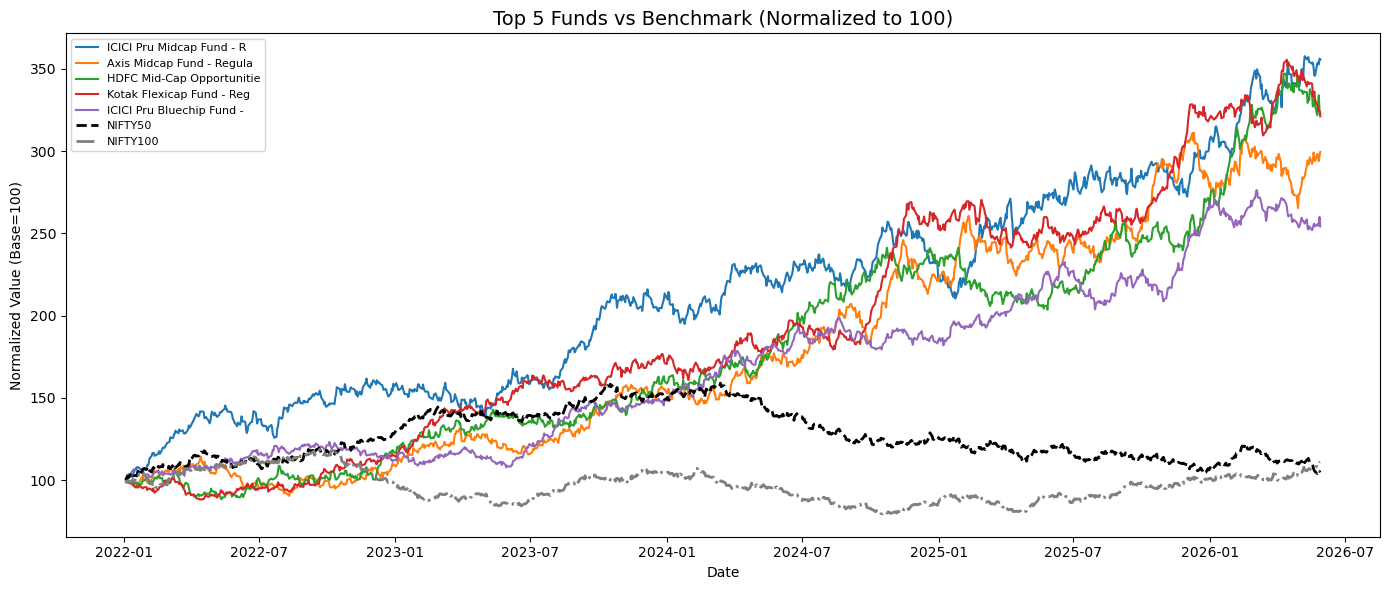

✓ Benchmark chart done!


In [9]:
# Top 5 funds vs Nifty 50 aur Nifty 100
# Normalized karo — sab 100 se shuru karenge

plt.figure(figsize=(14,6))

top5_codes = scorecard.head(5)['amfi_code'].tolist()

for code in top5_codes:
    fund = nav[nav['amfi_code']==code].sort_values('date')
    fund = fund[fund['date'] >= '2022-01-01']
    normalized = fund['nav'] / fund['nav'].iloc[0] * 100
    name = fund_master[fund_master['amfi_code']==code]['scheme_name'].values[0]
    plt.plot(fund['date'], normalized, linewidth=1.5,
             label=name[:25])

# Benchmarks plot karo
for idx_name, color, style in [('NIFTY50','black','--'),
                                 ('NIFTY100','gray','-.')]:
    idx = benchmark[benchmark['index_name']==idx_name].sort_values('date')
    idx = idx[idx['date'] >= '2022-01-01']
    normalized = idx['close_value'] / idx['close_value'].iloc[0] * 100
    plt.plot(idx['date'], normalized, color=color,
             linestyle=style, linewidth=2, label=idx_name)

plt.title('Top 5 Funds vs Benchmark (Normalized to 100)', fontsize=14)
plt.ylabel('Normalized Value (Base=100)')
plt.xlabel('Date')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150)
plt.show()
print("✓ Benchmark chart done!")

In [10]:
import os

# Save all results
cagr_df.to_csv('cagr_report.csv', index=False)
sharpe_df.to_csv('sharpe_values.csv', index=False)
sortino_df.to_csv('sortino_values.csv', index=False)
dd_df.to_csv('max_drawdown.csv', index=False)

print("=" * 50)
print("PERFORMANCE ANALYTICS COMPLETE! 🎉")
print("=" * 50)
print("\nFiles saved:")
for f in os.listdir('.'):
    if f.endswith('.csv') and f in ['fund_scorecard.csv','alpha_beta.csv',
                                      'cagr_report.csv','sharpe_values.csv',
                                      'max_drawdown.csv']:
        print(f"  ✓ {f}")
print("\n  ✓ benchmark_comparison.png")
print("\nDeliverables ready!")

PERFORMANCE ANALYTICS COMPLETE! 🎉

Files saved:
  ✓ alpha_beta.csv
  ✓ cagr_report.csv
  ✓ fund_scorecard.csv
  ✓ max_drawdown.csv
  ✓ sharpe_values.csv

  ✓ benchmark_comparison.png

Deliverables ready!


In [11]:
import pandas as pd
import shutil, os

CSV = r"C:\Users\Aman Karwal\Downloads\bluestock-mf-capstone\\"
BASE = r"C:\Users\Aman Karwal\bluestock_mf_capstone\\"

# Power BI folder banao
PBI = BASE + "dashboard\\"
os.makedirs(PBI, exist_ok=True)

# Saari files copy karo dashboard folder mein
files = [
    "01_fund_master.csv",
    "02_nav_history.csv", 
    "03_aum_by_fund_house.csv",
    "04_monthly_sip_inflows.csv",
    "05_category_inflows.csv",
    "06_industry_folio_count.csv",
    "07_scheme_performance.csv",
    "08_investor_transactions.csv",
    "09_portfolio_holdings.csv",
    "10_benchmark_indices.csv"
]

for f in files:
    shutil.copy(CSV + f, PBI + f)
    print(f"✓ {f}")

# Scorecard bhi copy karo
src = r"C:\Users\Aman Karwal\fund_scorecard.csv"
if os.path.exists(src):
    shutil.copy(src, PBI + "fund_scorecard.csv")
    print("✓ fund_scorecard.csv")

print(f"\n✓ Sab ready hai Power BI ke liye!")
print(f"Folder: {PBI}")

✓ 01_fund_master.csv
✓ 02_nav_history.csv
✓ 03_aum_by_fund_house.csv
✓ 04_monthly_sip_inflows.csv
✓ 05_category_inflows.csv
✓ 06_industry_folio_count.csv
✓ 07_scheme_performance.csv
✓ 08_investor_transactions.csv
✓ 09_portfolio_holdings.csv
✓ 10_benchmark_indices.csv
✓ fund_scorecard.csv

✓ Sab ready hai Power BI ke liye!
Folder: C:\Users\Aman Karwal\bluestock_mf_capstone\\dashboard\


In [12]:
import shutil, os

src  = r"C:\Users\Aman Karwal\fund_scorecard.csv"
dest = r"C:\Users\Aman Karwal\bluestock_mf_capstone\dashboard\\"

os.makedirs(dest, exist_ok=True)
shutil.copy(src, dest)
print("✓ fund_scorecard.csv copy ho gaya!")

# Confirm karo
print("\nDashboard folder mein files:")
for f in os.listdir(dest):
    print(f"  {f}")

✓ fund_scorecard.csv copy ho gaya!

Dashboard folder mein files:
  01_fund_master.csv
  02_nav_history.csv
  03_aum_by_fund_house.csv
  04_monthly_sip_inflows.csv
  05_category_inflows.csv
  06_industry_folio_count.csv
  07_scheme_performance.csv
  08_investor_transactions.csv
  09_portfolio_holdings.csv
  10_benchmark_indices.csv
  fund_scorecard.csv
